# experiment_v2_two_layer_attention.ipynb

Two-layer attention (SA + CA) variant of the bootstrap experiment.
Uses `CytokineABMIL_V2` with `TwoLayerAttentionModule` instead of the
standard single-layer `CytokineABMIL`.

Cytokine sampling mirrors `experiment_bootstrap.ipynb` exactly:
- Same `BOOTSTRAP_SEED`, `SIMPLE_POOL`, `COMPLEX_POOL`.
- Same `VAL_DONORS = ["Donor2", "Donor3"]`.
- Adds a **Layer Specialization Analysis** section at the end.

Pre-registered hypothesis: simple cytokines rank higher in learnability AUC
than complex cytokines (one-sided Mann-Whitney U, never re-tested).

In [1]:
import json
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from scipy.stats import mannwhitneyu, spearmanr

from cytokine_mil.data.dataset import CellDataset, PseudoTubeDataset
from cytokine_mil.data.label_encoder import CytokineLabel
from cytokine_mil.training.train_encoder import train_encoder
from cytokine_mil.training.train_mil import train_mil
from cytokine_mil.experiment_setup import (
    build_stage1_manifest,
    filter_manifest,
    split_manifest_by_donor,
    build_encoder,
)
from cytokine_mil.models.two_layer_attention import TwoLayerAttentionModule
from cytokine_mil.models.cytokine_abmil_v2 import CytokineABMIL_V2
from cytokine_mil.analysis.dynamics import (
    aggregate_to_donor_level,
    rank_cytokines_by_learnability,
    compute_cytokine_entropy_summary,
    compute_confusion_entropy_summary,
)
from torch.utils.data import DataLoader

## Top-level controls

In [2]:
BOOTSTRAP_SEED     = 42   # Controls which 5+5 cytokines are sampled from the pools.
N_SAMPLE_PER_GROUP = 5

CONFIG_PATH   = "cytokines/cytokines-mil/configs/default.yaml"
MANIFEST_PATH = "/cs/labs/mornitzan/yam.arieli/datasets/Oesinghaus_pseudotubes/manifest.json"
HVG_PATH      = "/cs/labs/mornitzan/yam.arieli/datasets/Oesinghaus_pseudotubes/hvg_list.json"

VAL_DONORS = ["Donor2", "Donor3"]

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

with open(HVG_PATH) as f:
    gene_names = json.load(f)

print(f"Bootstrap seed:  {BOOTSTRAP_SEED}  (controls cytokine sampling)")
print(f"Val donors:      {VAL_DONORS}")
print(f"Config:          {cfg}")

Bootstrap seed:  42  (controls cytokine sampling)
Val donors:      ['Donor2', 'Donor3']
Config:          {'data': {'manifest_path': '/cs/labs/mornitzan/yam.arieli/datasets/Oesinghaus_pseudotubes/manifest.json', 'n_hvgs': 4000, 'n_per_cell_type': 30, 'min_cells_threshold': 10, 'n_pseudo_tubes': 10}, 'model': {'embedding_dim': 128, 'attention_hidden_dim': 64, 'n_classes': 91}, 'training': {'stage1_epochs': 50, 'stage2_epochs': 100, 'stage3_epochs': 50, 'optimizer': 'sgd', 'momentum': 0.9, 'lr': 0.01, 'lr_scheduler': None, 'lr_warmup_epochs': 5}, 'dynamics': {'log_every_n_epochs': 1, 'random_seeds': [42, 123, 7]}}


## Load manifest

In [3]:
with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

manifest_cytokines = {e["cytokine"] for e in manifest}
print(f"Total manifest entries: {len(manifest)}")
print(f"Unique cytokines:       {len(manifest_cytokines)}")

Total manifest entries: 10920
Unique cytokines:       91


## Cytokine pools

Name corrections: IL-1β → `IL-1-beta`, IFN-β → `IFN-beta`, IL-32β → `IL-32-beta`, TGF-β → `TGF-beta1`.

In [4]:
SIMPLE_POOL = [
    "IL-4", "IL-10", "IL-2", "M-CSF", "TNF-alpha",
    "IL-1-beta", "IFN-beta", "IL-7", "G-CSF",
]

COMPLEX_POOL = [
    "IL-12", "IL-32-beta", "OSM", "IL-22", "VEGF",
    "HGF", "TGF-beta1", "IL-6",
]

missing_simple  = [c for c in SIMPLE_POOL  if c not in manifest_cytokines]
missing_complex = [c for c in COMPLEX_POOL if c not in manifest_cytokines]
if missing_simple or missing_complex:
    print(f"WARNING — missing from manifest: simple={missing_simple}  complex={missing_complex}")
else:
    print(f"Simple pool  ({len(SIMPLE_POOL)}): {SIMPLE_POOL}")
    print(f"Complex pool ({len(COMPLEX_POOL)}): {COMPLEX_POOL}")

Simple pool  (9): ['IL-4', 'IL-10', 'IL-2', 'M-CSF', 'TNF-alpha', 'IL-1-beta', 'IFN-beta', 'IL-7', 'G-CSF']
Complex pool (8): ['IL-12', 'IL-32-beta', 'OSM', 'IL-22', 'VEGF', 'HGF', 'TGF-beta1', 'IL-6']


## Bootstrap sampling

Sampling is seeded by `BOOTSTRAP_SEED`.

In [5]:
# BOOTSTRAP_SEED is defined in the top-level controls cell above.
_rng = random.Random(BOOTSTRAP_SEED)
SIMPLE_CYTOKINES  = sorted(_rng.sample(SIMPLE_POOL,  N_SAMPLE_PER_GROUP))
COMPLEX_CYTOKINES = sorted(_rng.sample(COMPLEX_POOL, N_SAMPLE_PER_GROUP))
SUBSET_CYTOKINES  = SIMPLE_CYTOKINES + COMPLEX_CYTOKINES

print(f"Bootstrap seed:  {BOOTSTRAP_SEED}")
print(f"SIMPLE:  {SIMPLE_CYTOKINES}")
print(f"COMPLEX: {COMPLEX_CYTOKINES}")
print(f"Total subset (excl. PBS): {len(SUBSET_CYTOKINES)}")

Bootstrap seed:  42
SIMPLE:  ['G-CSF', 'IL-1-beta', 'IL-10', 'IL-2', 'IL-4']
COMPLEX: ['HGF', 'IL-12', 'IL-22', 'IL-32-beta', 'VEGF']
Total subset (excl. PBS): 10


## Filter manifest to subset

In [6]:
subset_manifest = filter_manifest(manifest, SUBSET_CYTOKINES, include_pbs=True)

label_encoder = CytokineLabel().fit(subset_manifest)
LABEL_ENCODER_PATH = str(
    Path(MANIFEST_PATH).parent / f"label_encoder_v2_bootstrap_{BOOTSTRAP_SEED}.json"
)
label_encoder.save(LABEL_ENCODER_PATH)

train_manifest, val_manifest = split_manifest_by_donor(subset_manifest, val_donors=VAL_DONORS)

SUBSET_MANIFEST_PATH = str(Path(MANIFEST_PATH).parent / f"manifest_v2_bootstrap_{BOOTSTRAP_SEED}.json")
TRAIN_MANIFEST_PATH  = str(Path(MANIFEST_PATH).parent / f"manifest_v2_bootstrap_{BOOTSTRAP_SEED}_train.json")
VAL_MANIFEST_PATH    = str(Path(MANIFEST_PATH).parent / f"manifest_v2_bootstrap_{BOOTSTRAP_SEED}_val.json")

with open(SUBSET_MANIFEST_PATH, "w") as f:
    json.dump(subset_manifest, f)
with open(TRAIN_MANIFEST_PATH, "w") as f:
    json.dump(train_manifest, f)
with open(VAL_MANIFEST_PATH, "w") as f:
    json.dump(val_manifest, f)

print(f"Subset entries: {len(subset_manifest)}  (train: {len(train_manifest)}, val: {len(val_manifest)})")

Subset entries: 1320  (train: 1100, val: 220)


## Stage 1 manifest (one tube per cytokine for encoder pre-training)

In [7]:
STAGE1_MANIFEST_PATH = str(
    Path(MANIFEST_PATH).parent / f"manifest_stage1_v2_bootstrap_{BOOTSTRAP_SEED}.json"
)
_stage1_manifest = build_stage1_manifest(train_manifest, save_path=STAGE1_MANIFEST_PATH)
print(f"Stage 1 manifest entries: {len(_stage1_manifest)}")

Stage 1 manifest entries: 11


## Stage 1 — shared encoder pre-training (cell-type classification)

In [8]:
cell_dataset = CellDataset(STAGE1_MANIFEST_PATH, gene_names=gene_names, preload=True)
cell_loader  = DataLoader(cell_dataset, batch_size=256, shuffle=True, num_workers=0)

n_cell_types = cell_dataset.n_cell_types()
n_genes      = len(gene_names)

encoder = build_encoder(
    n_input_genes=n_genes,
    n_cell_types=n_cell_types,
    embed_dim=cfg["model"]["embedding_dim"],
)

encoder = train_encoder(
    encoder, cell_loader,
    # n_epochs=cfg["training"]["stage1_epochs"],
    n_epochs=8,
    lr=cfg["training"]["lr"],
    momentum=cfg["training"]["momentum"],
    verbose=True,
)

torch.save(encoder.state_dict(), f"encoder_stage1_v2_bootstrap_{BOOTSTRAP_SEED}.pt")
print("Stage 1 complete.")

[Stage 1] Epoch   1/8 | loss=2.0792 | acc=0.3927


[Stage 1] Epoch   2/8 | loss=0.5102 | acc=0.8162


[Stage 1] Epoch   3/8 | loss=0.3072 | acc=0.8899


[Stage 1] Epoch   4/8 | loss=0.2074 | acc=0.9246


[Stage 1] Epoch   5/8 | loss=0.1492 | acc=0.9509


[Stage 1] Epoch   6/8 | loss=0.0995 | acc=0.9731


[Stage 1] Epoch   7/8 | loss=0.0670 | acc=0.9832


[Stage 1] Epoch   8/8 | loss=0.0399 | acc=0.9952
Stage 1 complete.


## Build datasets for Stage 2

In [9]:
train_dataset = PseudoTubeDataset(TRAIN_MANIFEST_PATH, label_encoder)
val_dataset   = PseudoTubeDataset(VAL_MANIFEST_PATH,   label_encoder)

print(f"Train tubes: {len(train_dataset)}")
print(f"Val tubes:   {len(val_dataset)}")

Train tubes: 1100
Val tubes:   220


## Build CytokineABMIL_V2 (two-layer attention, frozen encoder)

In [10]:
attention = TwoLayerAttentionModule(
    embed_dim=cfg["model"]["embedding_dim"],
    attention_hidden_dim=cfg["model"]["attention_hidden_dim"],
)

mil_model = CytokineABMIL_V2(
    encoder=encoder,
    attention=attention,
    n_classes=label_encoder.n_classes(),
    embed_dim=cfg["model"]["embedding_dim"],
    encoder_frozen=True,
)

print(mil_model)

CytokineABMIL_V2(
  (encoder): InstanceEncoder(
    (input_proj): Sequential(
      (0): Linear(in_features=4000, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
    )
    (res1): _ResBlock(
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=512, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=512, bias=True)
      (act): GELU(approximate='none')
    )
    (down1): _DownBlock(
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=512, out_features=256, bias=True)
      (fc2): Linear(in_features=256, out_features=256, bias=True)
      (skip): Linear(in_features=512, out_features=256, bias=False)
      (act): GELU(approximate='none')
    )
    (res2): _ResBlock(
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=256, out_features=256, 

## Stage 2 — MIL training (frozen encoder)

In [11]:
cfg

{'data': {'manifest_path': '/cs/labs/mornitzan/yam.arieli/datasets/Oesinghaus_pseudotubes/manifest.json',
  'n_hvgs': 4000,
  'n_per_cell_type': 30,
  'min_cells_threshold': 10,
  'n_pseudo_tubes': 10},
 'model': {'embedding_dim': 128, 'attention_hidden_dim': 64, 'n_classes': 91},
 'training': {'stage1_epochs': 50,
  'stage2_epochs': 100,
  'stage3_epochs': 50,
  'optimizer': 'sgd',
  'momentum': 0.9,
  'lr': 0.01,
  'lr_scheduler': None,
  'lr_warmup_epochs': 5},
 'dynamics': {'log_every_n_epochs': 1, 'random_seeds': [42, 123, 7]}}

In [14]:
cfg["training"]["lr"] = 0.001
cfg["training"]["stage2_epochs"] = 40
cfg["training"]["lr_scheduler"] = 'cosine'

In [ ]:
dynamics_stage2 = train_mil(
    mil_model,
    train_dataset,
    n_epochs=cfg["training"]["stage2_epochs"],
    lr=cfg["training"]["lr"],
    momentum=cfg["training"]["momentum"],
    lr_scheduler=cfg["training"]["lr_scheduler"],
    lr_warmup_epochs=cfg["training"]["lr_warmup_epochs"],
    log_every_n_epochs=cfg["dynamics"]["log_every_n_epochs"],
    seed=BOOTSTRAP_SEED,
    verbose=True,
    val_dataset=val_dataset,
    kl_lambda=cfg["training"]["kl_lambda"],
    aux_loss_weight=cfg["training"]["aux_loss_weight"],
)

torch.save(mil_model.state_dict(), f"mil_stage2_v2_bootstrap_{BOOTSTRAP_SEED}.pt")

print(f"Train records: {len(dynamics_stage2['records'])}")
print(f"Val records:   {len(dynamics_stage2['val_records'])}")

## Stage 3 — optional fine-tuning (unfrozen encoder)

In [16]:
# mil_model.unfreeze_encoder()

# dynamics_stage3 = train_mil(
#     mil_model,
#     train_dataset,
#     n_epochs=cfg["training"]["stage3_epochs"],
#     lr=cfg["training"]["lr"] * 0.1,
#     momentum=cfg["training"]["momentum"],
#     log_every_n_epochs=cfg["dynamics"]["log_every_n_epochs"],
#     seed=BOOTSTRAP_SEED,
#     verbose=True,
#     val_dataset=val_dataset,
# )

# torch.save(mil_model.state_dict(), f"mil_stage3_v2_bootstrap_{BOOTSTRAP_SEED}.pt")
# print("Stage 3 complete.")

## Learnability ranking (Stage 2)

Metric: `AUC(mean_donor_p_correct_trajectory)` — median across pseudo-tubes per donor, then mean across donors.

In [17]:
donor_traj     = aggregate_to_donor_level(dynamics_stage2["records"])
val_donor_traj = aggregate_to_donor_level(dynamics_stage2["val_records"])

ranking_result     = rank_cytokines_by_learnability(donor_traj,     exclude=["PBS"])
val_ranking_result = rank_cytokines_by_learnability(val_donor_traj, exclude=["PBS"])

print(ranking_result["metric_description"])
print()
print(f"{'Cytokine':<20} {'Group':<10} {'AUC (train)':<14} {'AUC (val)'}")
print("-" * 60)

val_auc_map = dict(val_ranking_result["ranking"])
for cytokine, auc in ranking_result["ranking"]:
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    val_auc = val_auc_map.get(cytokine, float("nan"))
    print(f"{cytokine:<20} {group:<10} {auc:<14.4f} {val_auc:.4f}")

AUC of mean p_correct_trajectory across pseudo-tubes, aggregated to donor level (median across pseudo-tubes per donor, then mean across donors)

Cytokine             Group      AUC (train)    AUC (val)
------------------------------------------------------------
IL-32-beta           COMPLEX    32.3800        26.5753
IL-4                 SIMPLE     32.3363        24.0998
IL-2                 SIMPLE     30.9511        21.1215
IL-10                SIMPLE     30.4433        10.2080
IL-1-beta            SIMPLE     29.6634        6.6379
IL-12                COMPLEX    28.6254        19.8816
IL-22                COMPLEX    20.9686        2.0652
HGF                  COMPLEX    20.3881        3.0676
G-CSF                SIMPLE     19.7421        1.5225
VEGF                 COMPLEX    19.5428        5.6102


## Learning curves — Stage 2 (train vs val)

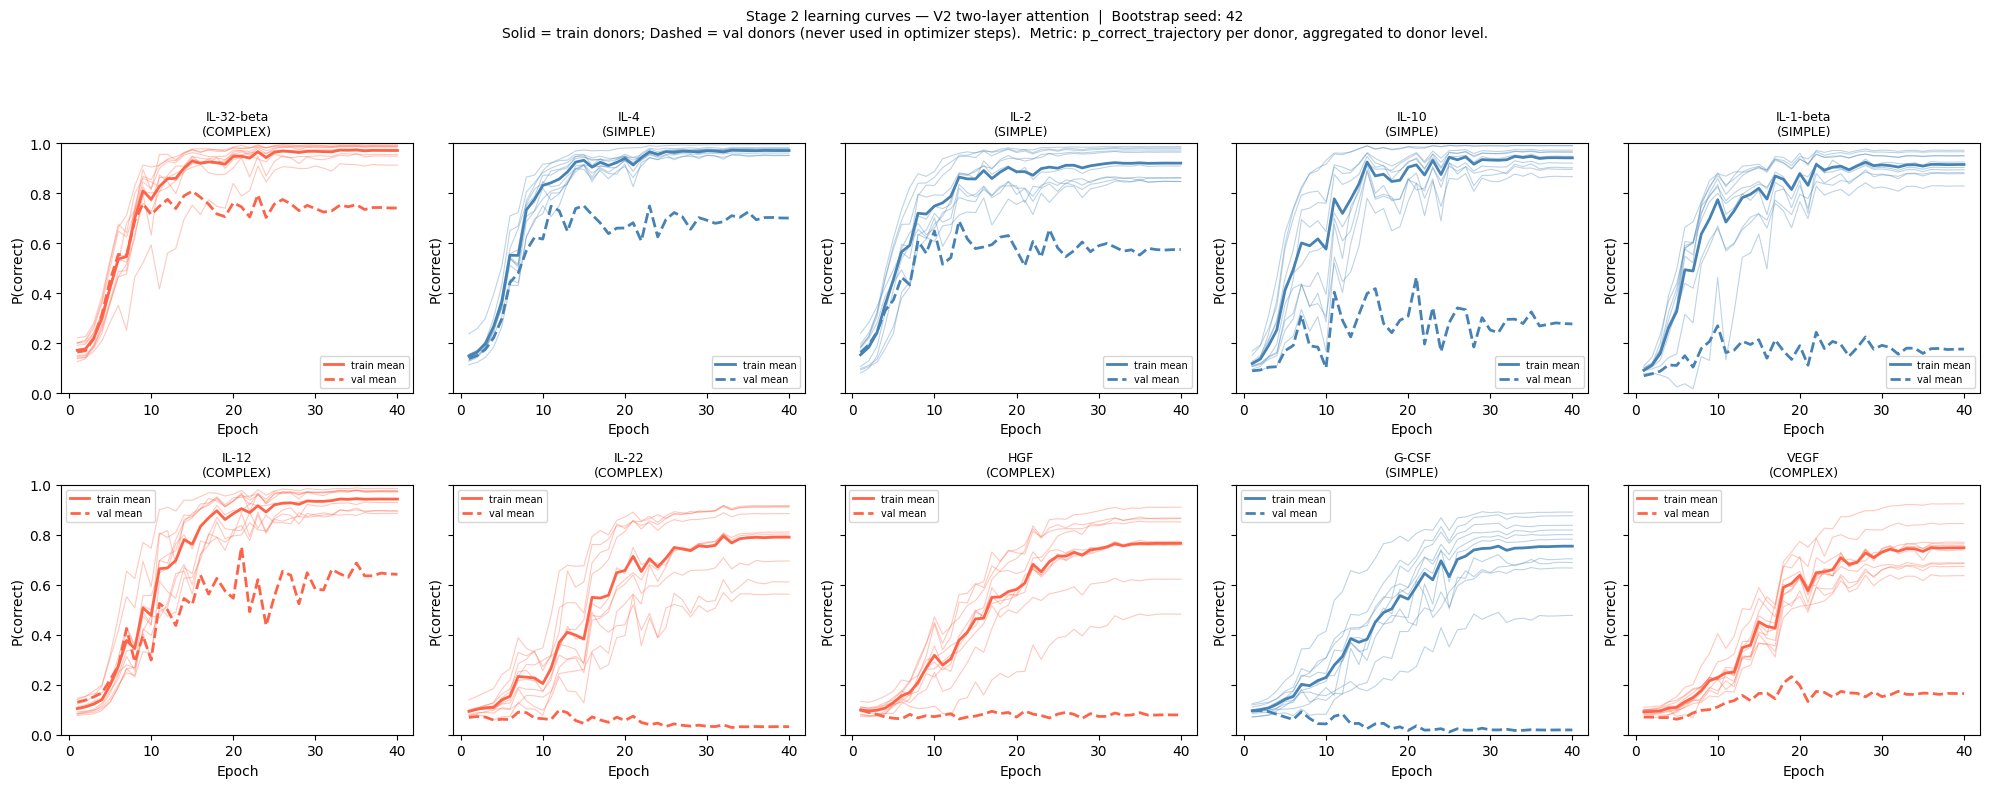

In [18]:
GROUP_COLOR = {"SIMPLE": "steelblue", "COMPLEX": "tomato"}

epochs = dynamics_stage2["logged_epochs"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

_auc_map = dict(ranking_result["ranking"])
_ordered = [(c, _auc_map[c]) for c in SIMPLE_CYTOKINES + COMPLEX_CYTOKINES if c in _auc_map]

for ax, (cytokine, _auc) in zip(axes, _ordered):
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    color = GROUP_COLOR[group]

    # Train
    if cytokine in donor_traj:
        for _donor, traj in donor_traj[cytokine].items():
            ax.plot(epochs, traj, alpha=0.35, color=color, linewidth=0.8)
        mean_traj = np.mean(list(donor_traj[cytokine].values()), axis=0)
        ax.plot(epochs, mean_traj, color=color, linewidth=2, label="train mean")

    # Val
    if cytokine in val_donor_traj:
        val_mean = np.mean(list(val_donor_traj[cytokine].values()), axis=0)
        ax.plot(epochs, val_mean, color=color, linewidth=2, linestyle="--", label="val mean")

    ax.set_title(f"{cytokine}\n({group})", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("P(correct)")
    ax.legend(fontsize=7)

fig.suptitle(
    f"Stage 2 learning curves — V2 two-layer attention  |  Bootstrap seed: {BOOTSTRAP_SEED}\n"
    "Solid = train donors; Dashed = val donors (never used in optimizer steps)."
    "  Metric: p_correct_trajectory per donor, aggregated to donor level.",
    fontsize=10,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"learning_curves_v2_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150)
plt.show()

## Attention entropy summary

In [19]:
entropy_result     = compute_cytokine_entropy_summary(dynamics_stage2["records"])
val_entropy_result = compute_cytokine_entropy_summary(dynamics_stage2["val_records"])

print(entropy_result["metric_description"])
print()
for cytokine, vals in sorted(
    entropy_result["summary"].items(), key=lambda x: x[1]["mean_entropy"], reverse=True
):
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    print(f"{cytokine:<20} {group:<10} H={vals['mean_entropy']:.4f} +/- {vals['std_entropy']:.4f}")

mean across epochs and pseudo-tubes of H(attention_weights) = -sum_i a_i * log(a_i), aggregated to donor level (median across pseudo-tubes per donor, then mean across donors)

IL-10                SIMPLE     H=4.1006 +/- 0.1513
PBS                  COMPLEX    H=4.0884 +/- 0.1254
IL-32-beta           COMPLEX    H=4.0440 +/- 0.3103
IL-4                 SIMPLE     H=3.9425 +/- 0.1398
IL-1-beta            SIMPLE     H=3.8550 +/- 0.2418
IL-2                 SIMPLE     H=3.7490 +/- 0.2185
VEGF                 COMPLEX    H=3.7166 +/- 0.2982
G-CSF                SIMPLE     H=3.6841 +/- 0.2864
HGF                  COMPLEX    H=3.5808 +/- 0.4595
IL-12                COMPLEX    H=3.5090 +/- 0.2875
IL-22                COMPLEX    H=3.5070 +/- 0.4113


## Confusion entropy summary

In [20]:
confusion_result = compute_confusion_entropy_summary(
    dynamics_stage2["confusion_entropy_trajectory"], exclude=["PBS"]
)
val_confusion_result = compute_confusion_entropy_summary(
    dynamics_stage2["val_confusion_entropy_trajectory"], exclude=["PBS"]
)

print(confusion_result["metric_description"])
print()
val_confusion_map = dict(val_confusion_result["ranking"])
for cytokine, auc in confusion_result["ranking"]:
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    val_v = val_confusion_map.get(cytokine, float("nan"))
    print(f"{cytokine:<20} {group:<10} AUC(H_confusion) train={auc:.4f}  val={val_v:.4f}")

AUC of H_confusion(C,t) = -sum_{k!=C} q_k(t) * log(q_k(t)), where q_k(t) is the renormalized off-diagonal mean softmax score across all pseudo-tubes of cytokine C at epoch t. Low = confusion concentrated on similar cytokines (similarity confound). High = confusion spread randomly (genuine difficulty).

IL-32-beta           COMPLEX    AUC(H_confusion) train=85.1030  val=75.1883
IL-4                 SIMPLE     AUC(H_confusion) train=81.1961  val=57.9265
HGF                  COMPLEX    AUC(H_confusion) train=72.3778  val=66.0342
VEGF                 COMPLEX    AUC(H_confusion) train=71.3953  val=61.3499
IL-12                COMPLEX    AUC(H_confusion) train=69.5716  val=61.8152
G-CSF                SIMPLE     AUC(H_confusion) train=69.0857  val=74.1198
IL-22                COMPLEX    AUC(H_confusion) train=66.9886  val=67.0620
IL-10                SIMPLE     AUC(H_confusion) train=65.0717  val=66.6075
IL-1-beta            SIMPLE     AUC(H_confusion) train=56.4268  val=57.9342
IL-2        

## Pre-registered hypothesis test

One-sided Mann-Whitney U: SIMPLE AUC > COMPLEX AUC (5 vs 5, donor-aggregated).
**Never repeated after unblinding.**

In [21]:
auc_map = dict(ranking_result["ranking"])

simple_aucs  = [auc_map[c] for c in SIMPLE_CYTOKINES  if c in auc_map]
complex_aucs = [auc_map[c] for c in COMPLEX_CYTOKINES if c in auc_map]

stat, p_value = mannwhitneyu(simple_aucs, complex_aucs, alternative="greater")

# Rank-biserial correlation r = 1 - 2*U / (n1*n2)
n1, n2 = len(simple_aucs), len(complex_aucs)
rbc = 1 - 2 * stat / (n1 * n2)

print(f"Bootstrap seed: {BOOTSTRAP_SEED}")
print(f"SIMPLE  AUCs: {[round(v, 4) for v in simple_aucs]}")
print(f"COMPLEX AUCs: {[round(v, 4) for v in complex_aucs]}")
print(f"Mann-Whitney U = {stat:.1f}  |  p (one-sided) = {p_value:.4f}")
print(f"Rank-biserial r = {rbc:.4f}  (low power: n=5 per group)")
print()
print("  Re-run with different BOOTSTRAP_SEED values to check robustness of the finding.")

Bootstrap seed: 42
SIMPLE  AUCs: [19.7421, 29.6634, 30.4433, 30.9511, 32.3363]
COMPLEX AUCs: [20.3881, 28.6254, 20.9686, 32.38, 19.5428]
Mann-Whitney U = 17.0  |  p (one-sided) = 0.2103
Rank-biserial r = -0.3600  (low power: n=5 per group)

  Re-run with different BOOTSTRAP_SEED values to check robustness of the finding.


## Generalization check (train vs val learnability ranking)

In [22]:
common_cytokines = sorted(
    set(dict(ranking_result["ranking"]).keys()) &
    set(dict(val_ranking_result["ranking"]).keys())
)
train_order = {c: rank for rank, (c, _) in enumerate(ranking_result["ranking"])}
val_order   = {c: rank for rank, (c, _) in enumerate(val_ranking_result["ranking"])}

train_ranks = [train_order[c] for c in common_cytokines]
val_ranks   = [val_order[c]   for c in common_cytokines]

rho, p_rho = spearmanr(train_ranks, val_ranks)

print(f"Generalization check — V2 two-layer attention  |  Bootstrap seed: {BOOTSTRAP_SEED}")
print(f"  Train donors: all except {VAL_DONORS}")
print(f"  Val donors:   {VAL_DONORS}  (never used in optimizer steps)")
print(f"  Spearman rho (train vs val ranking): {rho:.3f}  p={p_rho:.4f}")
print()
if rho > 0.6:
    print("  rho > 0.6 -> learnability ordering generalizes to held-out donors.")
else:
    print("  rho <= 0.6 -> possible donor memorization; interpret learnability ranking with caution.")

Generalization check — V2 two-layer attention  |  Bootstrap seed: 42
  Train donors: all except ['Donor2', 'Donor3']
  Val donors:   ['Donor2', 'Donor3']  (never used in optimizer steps)
  Spearman rho (train vs val ranking): 0.879  p=0.0008

  rho > 0.6 -> learnability ordering generalizes to held-out donors.


---

## Layer Specialization Analysis

Unique to the V2 architecture. Each tube now has two attention distributions:
- **SA layer** (`a_SA`): standard first-pass attention over cell embeddings.
- **CA layer** (`a_CA`): conditioned on the SA aggregate `z_SA`.

Questions addressed here:
1. Do SA and CA learn different `p_correct` trajectories?
2. Do they attend to different cells (divergence metric)?
3. Which layer specialises to which cell types?

### 1. SA vs CA p_correct trajectories per cytokine

The `p_correct_trajectory` stored in records is computed from SA attention
(used as the primary signal). `confidence_trajectory_sa` and
`confidence_trajectory_ca` store the full per-cell trajectories for each layer.

Here we derive a proxy for each layer's contribution by computing the mean
confidence across cells for SA and CA respectively:
- `mean_C_SA(t) = mean_i(a_SA_i(t)) * p_correct(t)`  (= p_correct(t) / N)
- But more meaningfully: sum of `confidence_trajectory_sa` and `_ca` both equal
  `p_correct(t)` by construction (attention sums to 1).

So we compare the *distribution* of attention mass across cells, not the scalar sum.

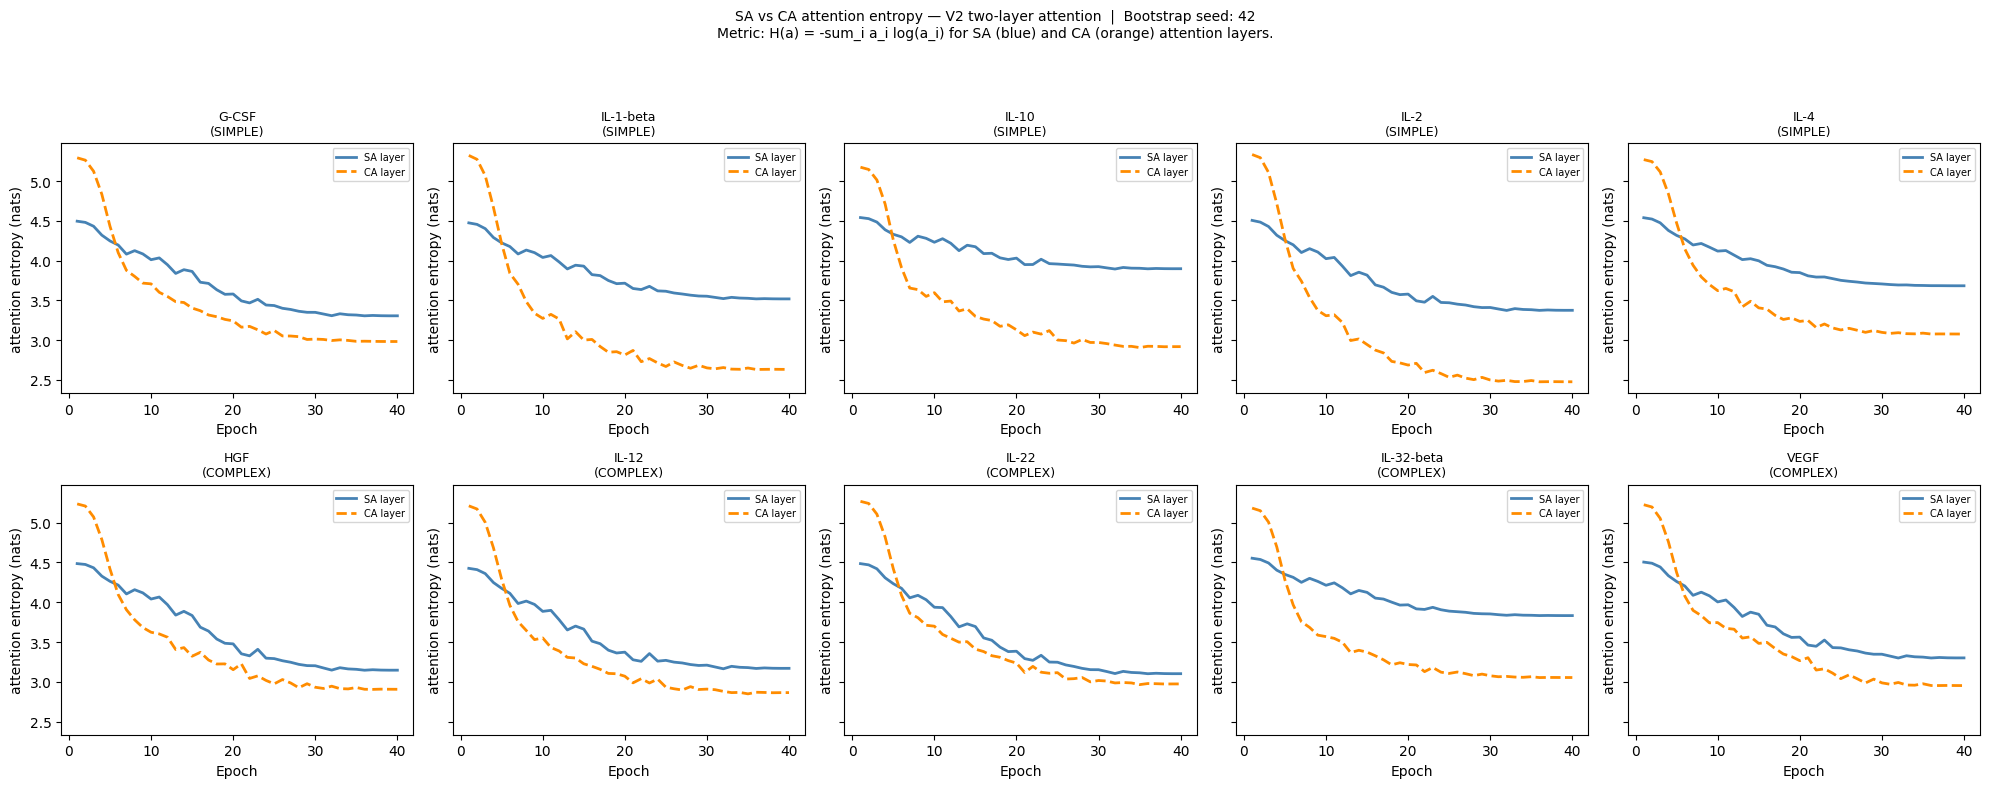

In [26]:
def _extract_layer_entropy(records, cytokine):
    """
    For each tube of the given cytokine, extract the SA and CA attention entropy
    trajectories stored in records.

    SA entropy is stored in 'entropy_trajectory'; CA entropy in 'entropy_trajectory_ca'.
    These differ because SA and CA attend to different cells with different specificity.

    Returns:
        sa_curves: list of (n_logged_epochs,) arrays, one per tube.
        ca_curves: list of (n_logged_epochs,) arrays, one per tube.
    """
    sa_curves, ca_curves = [], []
    for rec in records:
        if rec["cytokine"] != cytokine:
            continue
        sa_traj = rec.get("entropy_trajectory")
        ca_traj = rec.get("entropy_trajectory_ca")
        if sa_traj is None or ca_traj is None:
            continue
        sa_curves.append(np.array(sa_traj))   # (n_logged_epochs,)
        ca_curves.append(np.array(ca_traj))   # (n_logged_epochs,)
    return sa_curves, ca_curves


epochs = dynamics_stage2["logged_epochs"]
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

_auc_map = dict(ranking_result["ranking"])
_ordered = [(c, _auc_map[c]) for c in SIMPLE_CYTOKINES + COMPLEX_CYTOKINES if c in _auc_map]

for ax, (cytokine, _) in zip(axes, _ordered):
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    sa_curves, ca_curves = _extract_layer_entropy(
        dynamics_stage2["records"], cytokine
    )
    if sa_curves:
        mean_sa = np.mean(sa_curves, axis=0)
        mean_ca = np.mean(ca_curves, axis=0)
        ax.plot(epochs, mean_sa, color="steelblue",  linewidth=2, label="SA layer")
        ax.plot(epochs, mean_ca, color="darkorange", linewidth=2, label="CA layer", linestyle="--")
    ax.set_title(f"{cytokine}\n({group})", fontsize=9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("attention entropy (nats)")
    ax.legend(fontsize=7)

fig.suptitle(
    f"SA vs CA attention entropy — V2 two-layer attention  |  Bootstrap seed: {BOOTSTRAP_SEED}\n"
    "Metric: H(a) = -sum_i a_i log(a_i) for SA (blue) and CA (orange) attention layers.",
    fontsize=10,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"sa_vs_ca_entropy_v2_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150)
plt.show()

### 2. Attention overlap score per cytokine

For each tube, compute:
```
overlap(t) = sum_i min(a_SA_i(t), a_CA_i(t))
```
- `overlap = 1` → SA and CA attend identically (fully redundant).
- `overlap = 0` → SA and CA attend to completely different cells (fully specialized).

Mean across tubes per cytokine, then across logged epochs.

**Metric:** `mean_t mean_tubes sum_i min(a_SA_i(t), a_CA_i(t))` —
attention overlap score (0 = fully specialized, 1 = identical).

In [ ]:
def _compute_attention_overlap(
    records,
    key_sa="confidence_trajectory_sa",
    key_ca="confidence_trajectory_ca",
):
    """
    Compute mean attention overlap score per cytokine across tubes and epochs.

    overlap(tube, t) = sum_i min(a_SA_i(t), a_CA_i(t))

    C_SA_i(t) = a_SA_i(t) * p_correct(t)  and similarly for CA.
    To recover a_SA_i(t) from C_SA_i(t) we divide by p_correct(t).
    Tubes/epochs where p_correct is zero are skipped.

    Returns:
        overlap_per_cytokine: {cytokine -> float} mean overlap score.
        overlap_trajectory: {cytokine -> np.array(n_logged_epochs)} mean overlap over time.
    """
    raw = defaultdict(list)  # cytokine -> list of (n_logged_epochs,) arrays
    for rec in records:
        csa = rec.get(key_sa)
        cca = rec.get(key_ca)
        if csa is None or cca is None:
            continue
        # csa shape: (n_cells, n_logged_epochs)
        p_traj = np.array(rec["p_correct_trajectory"])  # (n_logged_epochs,)
        # Avoid division by zero; skip epochs where p_correct == 0.
        safe_p = np.where(p_traj > 1e-10, p_traj, np.nan)
        a_sa = csa / safe_p[np.newaxis, :]  # (n_cells, n_logged_epochs)
        a_ca = cca / safe_p[np.newaxis, :]  # (n_cells, n_logged_epochs)
        # sum_i min(a_SA_i, a_CA_i) for each epoch
        overlap_traj = np.nansum(
            np.minimum(a_sa, a_ca), axis=0
        )  # (n_logged_epochs,)
        raw[rec["cytokine"]].append(overlap_traj)

    overlap_per_cytokine = {}
    overlap_trajectory   = {}
    for cytokine, trajs in raw.items():
        stacked = np.stack(trajs, axis=0)            # (n_tubes, n_logged_epochs)
        mean_traj = np.nanmean(stacked, axis=0)      # (n_logged_epochs,)
        overlap_trajectory[cytokine]   = mean_traj
        overlap_per_cytokine[cytokine] = float(np.nanmean(mean_traj))
    return overlap_per_cytokine, overlap_trajectory


overlap_scores, overlap_trajs = _compute_attention_overlap(dynamics_stage2["records"])

print("Attention overlap score per cytokine")
print("Metric: mean_t mean_tubes sum_i min(a_SA_i(t), a_CA_i(t))")
print("  0 = fully specialized (SA and CA attend to different cells)")
print("  1 = identical (SA and CA attend identically)")
print()
for cytokine, score in sorted(overlap_scores.items(), key=lambda x: x[1]):
    if cytokine == "PBS":
        continue
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    print(f"{cytokine:<20} {group:<10} overlap={score:.4f}")

Attention overlap score per cytokine
Metric: mean_t mean_tubes sum_i min(a_SA_i(t), a_CA_i(t))
  0 = fully specialized (SA and CA attend to different cells)
  1 = identical (SA and CA attend identically)

IL-12                COMPLEX    overlap=0.0265
IL-1-beta            SIMPLE     overlap=0.0333
IL-2                 SIMPLE     overlap=0.0360
IL-22                COMPLEX    overlap=0.0367
IL-4                 SIMPLE     overlap=0.0373
G-CSF                SIMPLE     overlap=0.0383
VEGF                 COMPLEX    overlap=0.0395
HGF                  COMPLEX    overlap=0.0402
IL-32-beta           COMPLEX    overlap=0.0456
IL-10                SIMPLE     overlap=0.0472


### 3. Attention overlap trajectories over training

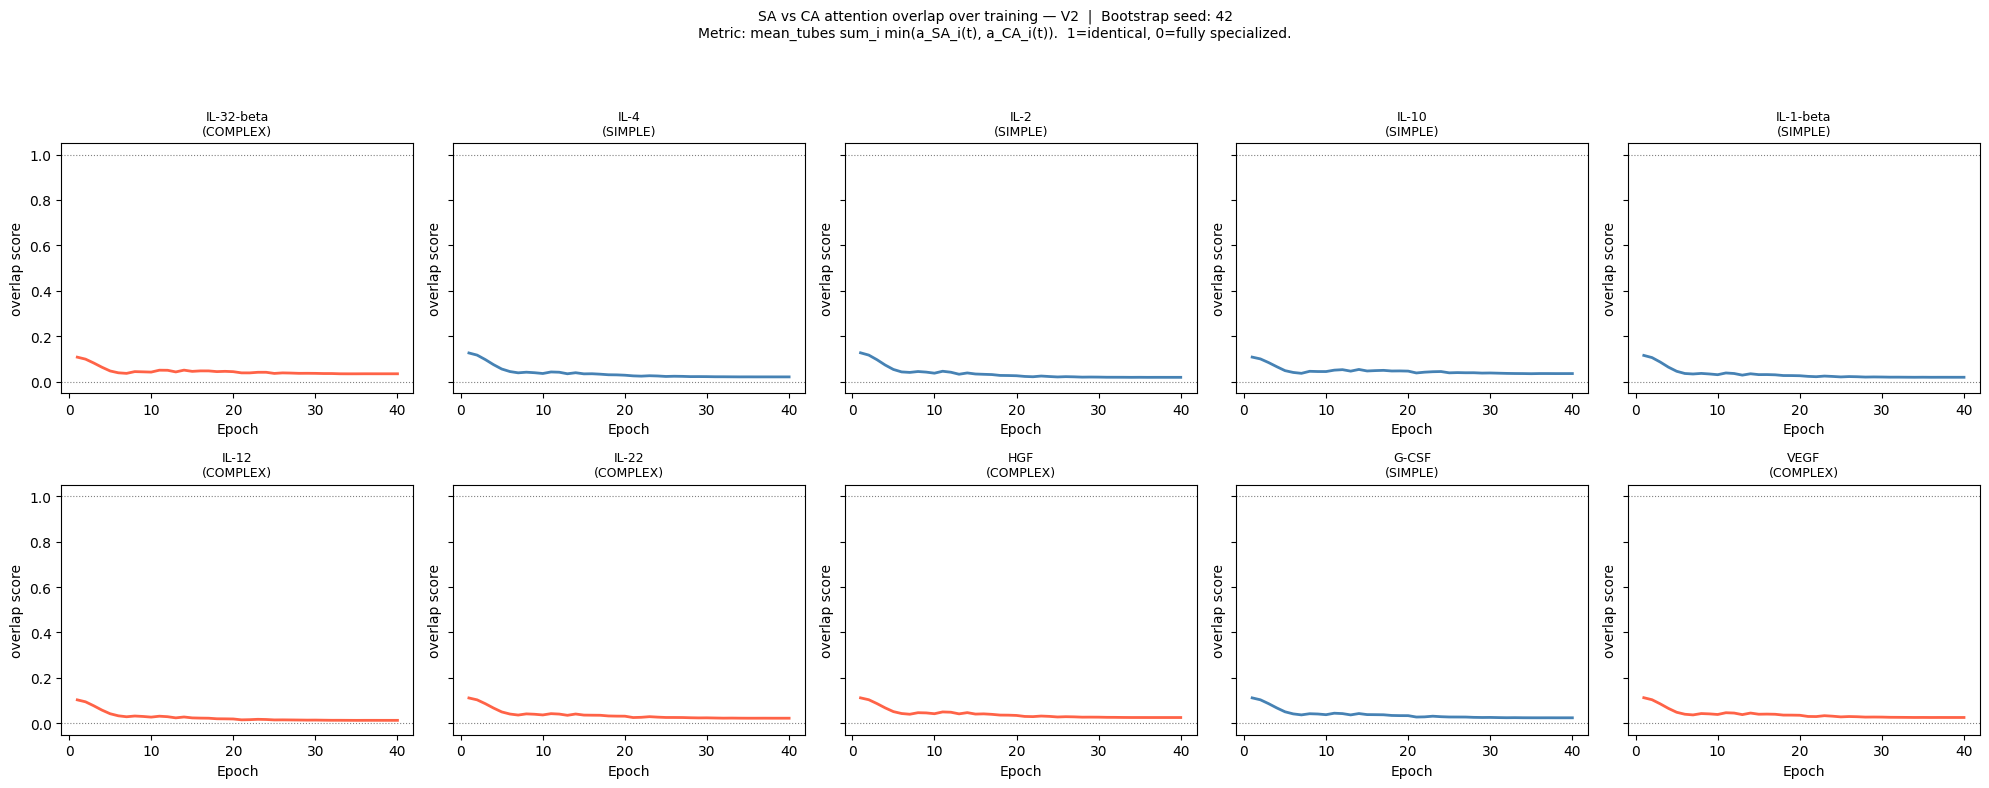

In [ ]:
epochs = dynamics_stage2["logged_epochs"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

_auc_map = dict(ranking_result["ranking"])
_ordered = [(c, _auc_map[c]) for c in SIMPLE_CYTOKINES + COMPLEX_CYTOKINES if c in _auc_map]

for ax, (cytokine, _) in zip(axes, _ordered):
    group = "SIMPLE" if cytokine in SIMPLE_CYTOKINES else "COMPLEX"
    color = GROUP_COLOR[group]
    traj = overlap_trajs.get(cytokine)
    if traj is not None and len(traj) == len(epochs):
        ax.plot(epochs, traj, color=color, linewidth=2)
        ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, label="identical")
        ax.axhline(0.0, color="gray", linestyle=":", linewidth=0.8, label="fully specialized")
    ax.set_title(f"{cytokine}\n({group})", fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("overlap score")

fig.suptitle(
    f"SA vs CA attention overlap over training — V2  |  Bootstrap seed: {BOOTSTRAP_SEED}\n"
    "Metric: mean_tubes sum_i min(a_SA_i(t), a_CA_i(t)).  1=identical, 0=fully specialized.",
    fontsize=10,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"attention_overlap_v2_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150)
plt.show()

In [ ]:
### 4. Loss components over training
#
# Verify the regularization is behaving as expected:
# - loss_kl should be positive initially (SA and CA attend differently).
# - loss_main, loss_sa, loss_ca should all decrease together.

lc = dynamics_stage2["loss_components"]
epochs_all = list(range(1, len(lc["total"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(epochs_all, lc["total"], label="total", color="black", lw=2)
ax.plot(epochs_all, lc["main"], label="main (combined)", color="steelblue", ls="--")
ax.plot(epochs_all, lc["sa_aux"], label="SA aux", color="darkorange", ls="--")
ax.plot(epochs_all, lc["ca_aux"], label="CA aux", color="seagreen", ls="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Classification Loss Components")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_all, lc["kl"], label="KL(a_CA || a_SA)", color="crimson", lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("KL divergence (batchmean / n_cytokines)")
ax.set_title("KL Regularization Loss")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Loss components — bootstrap seed {BOOTSTRAP_SEED}
"
    f"kl_lambda={cfg["training"]["kl_lambda"]} "
    f"aux_loss_weight={cfg["training"]["aux_loss_weight"]}",
    fontsize=10,
)
plt.tight_layout()
plt.savefig(f"loss_components_v2_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
### 5. SA vs CA entropy gap at convergence
#
# Key metric for whether regularization is driving specialization.
# gap > 0: CA is more diffuse than SA (CA broadens attention, consistent with cascade).
# gap < 0: CA is more focused than SA (unusual; worth investigating).
# gap ≈ 0: no specialization emerged.

def _entropy_gap_at_convergence(records, cytokine, last_n=5):
    """
    Compute mean(H(a_CA) - H(a_SA)) over tubes of the given cytokine,
    averaged over the final  logged epochs.
    Returns (mean_gap, sem_gap) across tubes.
    """
    gaps = []
    for rec in records:
        if rec["cytokine"] != cytokine:
            continue
        sa_traj = rec.get("entropy_trajectory") or []
        ca_traj = rec.get("entropy_trajectory_ca") or []
        if not sa_traj or not ca_traj:
            continue
        sa_end = float(np.mean(sa_traj[-last_n:]))
        ca_end = float(np.mean(ca_traj[-last_n:]))
        gaps.append(ca_end - sa_end)
    if not gaps:
        return 0.0, 0.0
    return float(np.mean(gaps)), float(np.std(gaps) / max(len(gaps) ** 0.5, 1))

cytokines_ordered = SIMPLE_CYTOKINES + COMPLEX_CYTOKINES
gaps_mean = []
gaps_sem = []
colors = ["steelblue" if c in SIMPLE_CYTOKINES else "tomato" for c in cytokines_ordered]

for cyt in cytokines_ordered:
    mean_g, sem_g = _entropy_gap_at_convergence(dynamics_stage2["records"], cyt)
    gaps_mean.append(mean_g)
    gaps_sem.append(sem_g)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(cytokines_ordered))
ax.bar(x, gaps_mean, yerr=gaps_sem, color=colors, capsize=4, alpha=0.8)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(cytokines_ordered, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Mean H(a_CA) - H(a_SA) at convergence (nats)")
ax.set_title(
    "SA vs CA entropy gap at convergence — bootstrap seed " + str(BOOTSTRAP_SEED) + "
"
    "Positive = CA more diffuse (cascade signal); blue = SIMPLE, red = COMPLEX"
)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"entropy_gap_v2_bootstrap_{BOOTSTRAP_SEED}.png", dpi=150, bbox_inches="tight")
plt.show()